In [2]:
import pandas as pd
# import numpy as np

df = pd.read_csv("./data/finalData.csv")

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
df

,Unnamed: 0,district,year,season,crop,area,production,yield,temperature,rainfall,humidity,nitrogen,phosphorus,potassium,organic_carbon,ph,micronutrient_score
0,0,north 24 parganas,1997,autumn,rice,15017.0,33840.0,2.253446,26.211844,116.509894,74.59828,0.440147,0.872612,0.545589,0.699294,6.904370,0.934015
1,1,north 24 parganas,1997,kharif,jute,52568.0,677510.0,12.888259,26.211844,116.509894,74.59828,0.440147,0.872612,0.545589,0.699294,6.904370,0.934015
2,2,north 24 parganas,1997,kharif,mesta,690.0,6710.0,9.724638,26.211844,116.509894,74.59828,0.440147,0.872612,0.545589,0.699294,6.904370,0.934015
3,3,north 24 parganas,1997,kharif,urad,1992.0,1310.0,0.657631,26.211844,116.509894,74.59828,0.440147,0.872612,0.545589,0.699294,6.904370,0.934015
4,4,north 24 parganas,1997,rabi,gram,267.0,160.0,0.599251,26.211844,116.509894,74.59828,0.440147,0.872612,0.545589,0.699294,6.904370,0.934015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14863,14863,puruliya,2014,summer,rice,306.0,801.0,2.617647,24.599167,1424.500000,66.01000,0.339032,0.869228,0.629282,0.342048,6.624502,0.551782
14864,14864,puruliya,2014,summer,sesamum,627.0,463.0,0.738437,24.599167,1424.500000,66.01000,0.339032,0.869228,0.629282,0.342048,6.624502,0.551782
14865,14865,puruliya,2014,whole year,sugarcane,324.0,16250.0,50.154321,24.599167,1424.500000,66.01000,0.339032,0.869228,0.629282,0.342048,6.624502,0.551782
14866,14866,puruliya,2014,winter,rice,279151.0,597899.0,2.141848,24.599167,1424.500000,66.01000,0.339032,0.869228,0.629282,0.342048,6.624502,0.551782


In [ ]:
# Top frequent crops
top_freq = df["crop"].value_counts().head(12).index

# Top yield crops
top_yield = df.groupby("crop")["yield"].mean().sort_values(ascending=False).head(12).index

# Intersection (best crops)
final_crops = list(set(top_freq).intersection(set(top_yield)))

# Filter dataset
df = df[df["crop"].isin(final_crops)]

print("Selected crops:", final_crops)
print("New dataset shape:", df.shape)

Selected crops: ['maize', 'jute', 'wheat', 'rice', 'potato']
New dataset shape: (3665, 17)


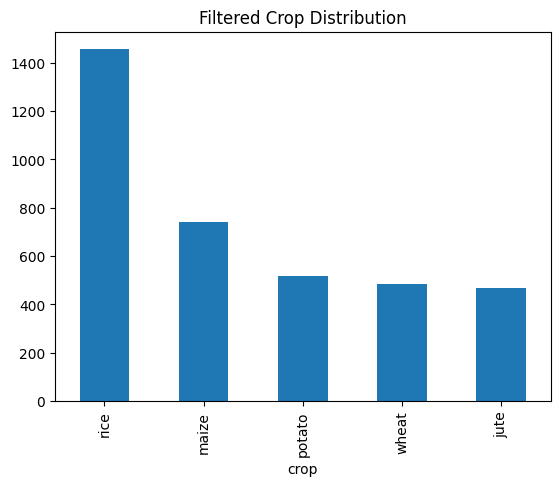

In [ ]:
import matplotlib.pyplot as plt

df["crop"].value_counts().plot(kind="bar")
plt.title("Filtered Crop Distribution")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_district = LabelEncoder()
le_season = LabelEncoder()
le_crop = LabelEncoder()

df["district"] = le_district.fit_transform(df["district"])
df["season"] = le_season.fit_transform(df["season"])
df["crop"] = le_crop.fit_transform(df["crop"])

/tmp/ipykernel_55/699930554.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["district"] = le_district.fit_transform(df["district"])
/tmp/ipykernel_55/699930554.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["season"] = le_season.fit_transform(df["season"])
/tmp/ipykernel_55/699930554.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

In [ ]:
X = df[[
    "district", "year", "season",
    "rainfall", "temperature", "humidity",
    "nitrogen", "phosphorus", "potassium",
    "organic_carbon", "ph", "micronutrient_score"
]]

y = df["crop"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.5416098226466576
              precision    recall  f1-score   support

           0       0.62      0.61      0.62        96
           1       0.10      0.10      0.10       151
           2       0.43      0.46      0.45       106
           3       0.74      0.76      0.75       279
           4       0.70      0.60      0.65       101

    accuracy                           0.54       733
   macro avg       0.52      0.51      0.51       733
weighted avg       0.54      0.54      0.54       733



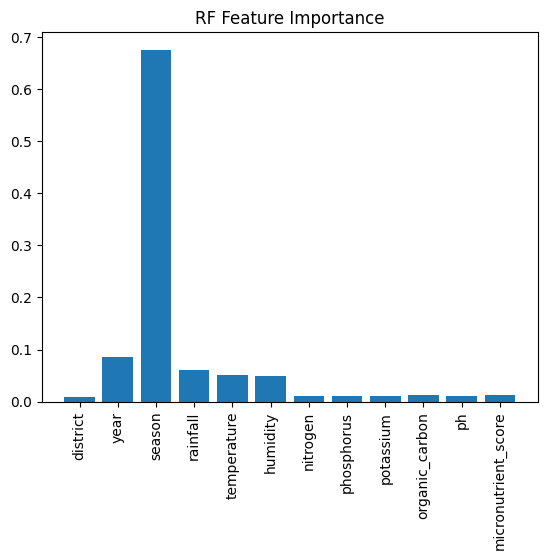

In [ ]:
plt.figure()
plt.bar(X.columns, rf_model.feature_importances_)
plt.title("RF Feature Importance")
plt.xticks(rotation=90)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train_nn = to_categorical(y_train)
y_test_nn = to_categorical(y_test)

2026-03-28 17:33:42.538129: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774719222.796549      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774719222.879918      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774719223.515188      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774719223.515307      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774719223.515311      55 computation_placer.cc:177] computation placer alr

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(y_train_nn.shape[1], activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-28 17:34:09.418426: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
history = model.fit(
    X_train_scaled, y_train_nn,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_scaled, y_test_nn),
    callbacks=[early_stop]
)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3481 - loss: 1.5326 - val_accuracy: 0.3874 - val_loss: 1.3795
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3920 - loss: 1.3718 - val_accuracy: 0.3915 - val_loss: 1.2703
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4124 - loss: 1.2693 - val_accuracy: 0.4284 - val_loss: 1.1845
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4559 - loss: 1.1763 - val_accuracy: 0.5198 - val_loss: 1.0964
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4889 - loss: 1.1163 - val_accuracy: 0.5252 - val_loss: 1.0109
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5302 - loss: 1.0511 - val_accuracy: 0.5730 - val_loss: 0.9530
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5605 - loss: 0.9629 - val_accuracy: 0.6153 - val_loss: 0.8851
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5870 - loss: 0.9294 - val_accuracy: 0.6235 - val_loss:

In [ ]:
loss, accuracy = model.evaluate(X_test_scaled, y_test_nn)

print("NN Accuracy:", accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6824 - loss: 0.5414 
NN Accuracy: 0.6903137564659119


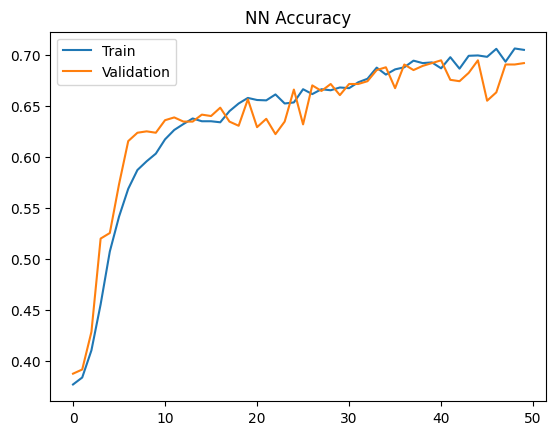

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("NN Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

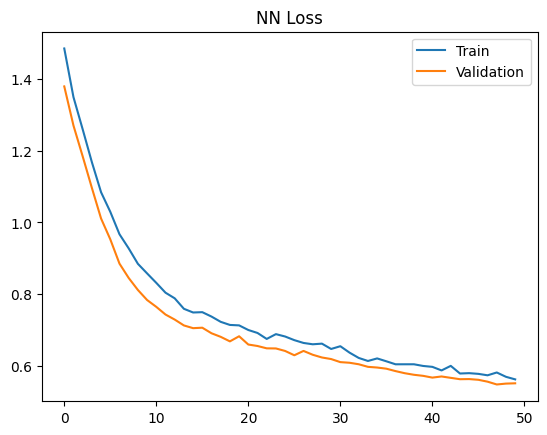

In [ ]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("NN Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)
print("Neural Network Accuracy:", accuracy)

Random Forest Accuracy: 0.5416098226466576
Neural Network Accuracy: 0.6903137564659119


In [ ]:
import pandas as pd
import numpy as np

def test_models(district, year, season,
                rainfall, temperature, humidity,
                nitrogen, phosphorus, potassium,
                organic_carbon, ph, micro):

    # 🔹 Clean input
    district = district.lower().strip()
    season = season.lower().strip()

    # 🔹 Encode
    d = le_district.transform([district])[0]
    s = le_season.transform([season])[0]

    # 🔹 Create input DataFrame (IMPORTANT)
    input_df = pd.DataFrame([{
        "district": d,
        "year": year,
        "season": s,
        "rainfall": rainfall,
        "temperature": temperature,
        "humidity": humidity,
        "nitrogen": nitrogen,
        "phosphorus": phosphorus,
        "potassium": potassium,
        "organic_carbon": organic_carbon,
        "ph": ph,
        "micronutrient_score": micro
    }])

    # =========================
    # 🌳 Random Forest
    # =========================
    rf_pred = rf_model.predict(input_df)
    rf_crop = le_crop.inverse_transform(rf_pred)[0]

    rf_probs = rf_model.predict_proba(input_df)[0]
    rf_top3_idx = np.argsort(rf_probs)[-3:][::-1]
    rf_top3 = [(le_crop.inverse_transform([i])[0], rf_probs[i]) for i in rf_top3_idx]

    # =========================
    # 🤖 Neural Network
    # =========================
    input_scaled = scaler.transform(input_df)

    nn_pred = model.predict(input_scaled, verbose=0)
    nn_class = np.argmax(nn_pred)
    nn_crop = le_crop.inverse_transform([nn_class])[0]

    nn_probs = nn_pred[0]
    nn_top3_idx = np.argsort(nn_probs)[-3:][::-1]
    nn_top3 = [(le_crop.inverse_transform([i])[0], nn_probs[i]) for i in nn_top3_idx]

    # =========================
    # 📊 OUTPUT
    # =========================
    print("\n🔍 INPUT:")
    print(input_df)

    print("\n🌳 Random Forest Prediction:", rf_crop)
    print("Top 3 RF Predictions:")
    for crop, prob in rf_top3:
        print(f"  {crop} → {prob:.3f}")

    print("\n🤖 Neural Network Prediction:", nn_crop)
    print("Top 3 NN Predictions:")
    for crop, prob in nn_top3:
        print(f"  {crop} → {prob:.3f}")

    return {
        "rf_prediction": rf_crop,
        "nn_prediction": nn_crop,
        "rf_top3": rf_top3,
        "nn_top3": nn_top3
    }

In [ ]:
test_models(
    district="bankura",
    year=2012,
    season="kharif",
    rainfall=1200,
    temperature=28,
    humidity=75,
    nitrogen=0.6,
    phosphorus=0.5,
    potassium=0.7,
    organic_carbon=0.4,
    ph=6.8,
    micro=0.8
)


🔍 INPUT:
   district  year  season  rainfall  temperature  humidity  nitrogen  \
0         0  2012       1      1200           28        75       0.6   

   phosphorus  potassium  organic_carbon   ph  micronutrient_score  
0         0.5        0.7             0.4  6.8                  0.8  

🌳 Random Forest Prediction: jute
Top 3 RF Predictions:
  jute → 0.765
  rice → 0.070
  wheat → 0.058

🤖 Neural Network Prediction: jute
Top 3 NN Predictions:
  jute → 0.976
  maize → 0.020
  potato → 0.003


{'rf_prediction': 'jute',
 'nn_prediction': 'jute',
 'rf_top3': [('jute', np.float64(0.7651666666666668)),
  ('rice', np.float64(0.07)),
  ('wheat', np.float64(0.0575))],
 'nn_top3': [('jute', np.float32(0.97579646)),
  ('maize', np.float32(0.020315409)),
  ('potato', np.float32(0.0026387488))]}

In [ ]:
print(df["district"].unique()[:10])

[13 15  0  1  2  9  4  3 16  7]


In [ ]:
df

,Unnamed: 0,district,year,season,crop,area,production,yield,temperature,rainfall,humidity,nitrogen,phosphorus,potassium,organic_carbon,ph,micronutrient_score
0,0,13,1997,0,3,15017.0,33840.0,2.253446,26.211844,116.509894,74.59828,0.440147,0.872612,0.545589,0.699294,6.904370,0.934015
1,1,13,1997,1,0,52568.0,677510.0,12.888259,26.211844,116.509894,74.59828,0.440147,0.872612,0.545589,0.699294,6.904370,0.934015
10,10,13,1997,2,4,6790.0,11950.0,1.759941,26.211844,116.509894,74.59828,0.440147,0.872612,0.545589,0.699294,6.904370,0.934015
12,12,13,1997,3,3,98044.0,269690.0,2.750704,26.211844,116.509894,74.59828,0.440147,0.872612,0.545589,0.699294,6.904370,0.934015
19,19,13,1997,4,1,5.0,10.0,2.000000,26.211844,116.509894,74.59828,0.440147,0.872612,0.545589,0.699294,6.904370,0.934015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14857,14857,14,2014,2,2,477.0,9995.0,20.953878,24.599167,1424.500000,66.01000,0.339032,0.869228,0.629282,0.342048,6.624502,0.551782
14861,14861,14,2014,2,4,1622.0,3663.0,2.258323,24.599167,1424.500000,66.01000,0.339032,0.869228,0.629282,0.342048,6.624502,0.551782
14862,14862,14,2014,3,1,325.0,2039.0,6.273846,24.599167,1424.500000,66.01000,0.339032,0.869228,0.629282,0.342048,6.624502,0.551782
14863,14863,14,2014,3,3,306.0,801.0,2.617647,24.599167,1424.500000,66.01000,0.339032,0.869228,0.629282,0.342048,6.624502,0.551782


In [ ]:
df_original = df.copy()   # for lookup (strings)
df_model = df.copy()      # for encoded model

In [ ]:
import pandas as pd
import numpy as np

def crop_recommendation(district, season):

    # ----------------------------
    # 🔹 Clean input
    # ----------------------------
    district = district.lower().strip()
    season = season.lower().strip()

    # ----------------------------
    # 🔹 CHECK DISTRICT EXISTS
    # ----------------------------
    if district not in df_original["district"].unique():
        print("❌ District not found in dataset")
        return None

    if season not in df_original["season"].unique():
        print("❌ Season not found in dataset")
        return None

    # ----------------------------
    # 🔹 GET WEATHER (AUTO)
    # ----------------------------
    subset = df_original[df_original["district"] == district]

    weather_row = subset[["rainfall", "temperature", "humidity"]].mean()

    # fallback if NaN
    if weather_row.isnull().any():
        weather_row = df_original[["rainfall", "temperature", "humidity"]].mean()

    rainfall = weather_row["rainfall"]
    temperature = weather_row["temperature"]
    humidity = weather_row["humidity"]

    # ----------------------------
    # 🔹 GET SOIL DATA (AUTO)
    # ----------------------------
    soil_row = subset[[
        "nitrogen", "phosphorus", "potassium",
        "organic_carbon", "ph", "micronutrient_score"
    ]].mean()

    if soil_row.isnull().any():
        soil_row = df_original[[
            "nitrogen", "phosphorus", "potassium",
            "organic_carbon", "ph", "micronutrient_score"
        ]].mean()

    nitrogen = soil_row["nitrogen"]
    phosphorus = soil_row["phosphorus"]
    potassium = soil_row["potassium"]
    organic_carbon = soil_row["organic_carbon"]
    ph_val = soil_row["ph"]
    micro = soil_row["micronutrient_score"]

    # ----------------------------
    # 🔹 ENCODE INPUT
    # ----------------------------
    d = le_district.transform([district])[0]
    s = le_season.transform([season])[0]

    year = df_original["year"].max()

    # ----------------------------
    # 🔹 CREATE INPUT DATA
    # ----------------------------
    input_df = pd.DataFrame([{
        "district": d,
        "year": year,
        "season": s,
        "rainfall": rainfall,
        "temperature": temperature,
        "humidity": humidity,
        "nitrogen": nitrogen,
        "phosphorus": phosphorus,
        "potassium": potassium,
        "organic_carbon": organic_carbon,
        "ph": ph_val,
        "micronutrient_score": micro
    }])

    # ----------------------------
    # 🌳 RANDOM FOREST
    # ----------------------------
    rf_pred = rf_model.predict(input_df)
    rf_crop = le_crop.inverse_transform(rf_pred)[0]

    # ----------------------------
    # 🤖 NEURAL NETWORK
    # ----------------------------
    input_scaled = scaler.transform(input_df)

    nn_pred = model.predict(input_scaled, verbose=0)
    nn_crop = le_crop.inverse_transform([np.argmax(nn_pred)])[0]

    # ----------------------------
    # 📊 OUTPUT
    # ----------------------------
    print("\n📍 District:", district)
    print("🌱 Season:", season)

    print("\n🌦️ Weather Used:")
    print(f"Rainfall: {rainfall:.2f}, Temp: {temperature:.2f}, Humidity: {humidity:.2f}")

    print("\n🌾 Soil Used:")
    print(f"N: {nitrogen:.2f}, P: {phosphorus:.2f}, K: {potassium:.2f}, pH: {ph_val:.2f}")

    print("\n🌳 RF Recommendation:", rf_crop)
    print("🤖 NN Recommendation:", nn_crop)

    return {
        "district": district,
        "season": season,
        "rf_crop": rf_crop,
        "nn_crop": nn_crop
    }

In [ ]:
smart_crop_recommendation(
    district="bankura",
    season="kharif"
)


📍 District: bankura
🌱 Season: kharif

🌦️ Estimated Weather:
Rainfall: nan, Temp: nan, Humidity: nan

🌾 Soil Condition:
N: nan, P: nan, K: nan, pH: nan

🌳 RF Recommended Crop: jute
🤖 NN Recommended Crop: jute


{'district': 'bankura',
 'season': 'kharif',
 'rf_crop': 'jute',
 'nn_crop': 'jute'}

proposed

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from sklearn.metrics import accuracy_score, mean_squared_error

In [ ]:
weather = weather_df.copy()

features = ["temperature", "rainfall", "humidity"]

# Create sequences
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

weather_data = weather[features].values

X_w, y_w = create_sequences(weather_data)

NameError: name 'weather_df' is not defined

In [ ]:
!pip install streamlit
import streamlit as st
import pandas as pd
import numpy as np

# Title
st.title("🌾 Crop Recommendation System")

st.write("Enter district and season to get recommended crops")

# ----------------------------
# INPUTS
# ----------------------------
district = st.selectbox(
    "Select District",
    sorted(df_original["district"].unique())
)

season = st.selectbox(
    "Select Season",
    sorted(df_original["season"].unique())
)

# ----------------------------
# BUTTON
# ----------------------------
if st.button("Recommend Crop"):

    result = crop_recommendation(district, season)

    if result:
        st.success("✅ Recommendation Generated")

        # Display results
        st.subheader("🌳 Random Forest Prediction")
        st.write(result["rf_crop"])

        st.subheader("🤖 Neural Network Prediction")
        st.write(result["nn_crop"])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 52.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 81.1 MB/s eta 0:00:00:00:0100:01


2026-03-28 17:50:15.729 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 17:50:16.242 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-28 17:50:16.243 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 17:50:16.244 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 17:50:16.245 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 17:50:16.246 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 17:50:16.247 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-28 17:50:16.249 Thread 'MainThread': mi